In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset


import torchvision
import torchvision.transforms as transforms


from sklearn.model_selection import train_test_split

import copy


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [2]:
class Custom_dataset(Dataset):
  def __init__(self, root_dir, csv_file=None, transform=None):

    self.root_dir = root_dir
    self.transform = transform
    self.csv_file = csv_file


    if csv_file is not None:
      self.annotations = pd.read_csv(csv_file)
    else:
      self.annotations = None
      self.image_ids = sorted(os.listdir(root_dir))

  def __len__(self):
    if self.annotations is not None:
      return len(self.annotations)
    return len(self.image_ids)

  def __getitem__(self, index):
    if self.annotations is not None:

      image_id = self.annotations.iloc[index, 0]
      label = int(self.annotations.iloc[index, 1])
    else:
      image_id = self.image_ids[index]
      label = image_id

    img_path = f"{self.root_dir}/{image_id}"
    image = Image.open(img_path).convert("RGB")

    if self.transform:
      image = self.transform(image)

    return image, label



def get_data_full(batch_size, transform_train):
    csv_file = '/kaggle/input/bhw-1-dl-2025-2026/bhw1/labels.csv'
    root_dir_trainval = '/kaggle/input/bhw-1-dl-2025-2026/bhw1/trainval'
    

    full_dataset = Custom_dataset(root_dir=root_dir_trainval, csv_file=csv_file, transform=transform_train)
    
    full_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    return full_loader


In [3]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

def test(model, test_loader):
    loss_log, acc_log = [], []

    model.eval()

    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            target = target.to(device)
            logits = model(data)
            loss = criterion(logits, target)
            loss_log.append(loss.item())

            preds = logits.argmax(dim=1)
            acc = (preds == target).float().mean()
            acc_log.append(acc.item())


    return np.mean(loss_log), np.mean(acc_log)

In [4]:
def train_epoch(model, optimizer, train_loader, criterion, device, scheduler, alpha=0.2):
    loss_log, acc_log = [], []
    model.train()

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        

        decision = np.random.rand()
        
        if alpha > 0 and decision > 0.5:

            lam = np.random.beta(alpha, alpha)
            index = torch.randperm(data.size(0)).to(device)
            mixed_data = lam * data + (1 - lam) * data[index, :]
            target_a, target_b = target, target[index]
            
        elif alpha > 0 and decision <= 0.5:

            lam = np.random.beta(alpha, alpha)
            index = torch.randperm(data.size(0)).to(device)
            

            W, H = data.size(2), data.size(3)
            cut_rat = np.sqrt(1. - lam)
            cut_w = int(W * cut_rat)
            cut_h = int(H * cut_rat)
            cx = np.random.randint(W)
            cy = np.random.randint(H)

            bbx1 = np.clip(cx - cut_w // 2, 0, W)
            bby1 = np.clip(cy - cut_h // 2, 0, H)
            bbx2 = np.clip(cx + cut_w // 2, 0, W)
            bby2 = np.clip(cy + cut_h // 2, 0, H)

            mixed_data = data.clone()
            mixed_data[:, :, bbx1:bbx2, bby1:bby2] = data[index, :, bbx1:bbx2, bby1:bby2]
            

            lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (W * H))
            target_a, target_b = target, target[index]
        else:
            mixed_data, target_a, target_b, lam = data, target, target, 1.0

        optimizer.zero_grad()
        logits = model(mixed_data)
        
        loss = lam * criterion(logits, target_a) + (1 - lam) * criterion(logits, target_b)
        loss.backward()
        optimizer.step()
        

        if scheduler is not None and not isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step()

        loss_log.append(loss.item())
        preds = logits.argmax(dim=1)
        acc = (lam * (preds == target_a).float() + (1 - lam) * (preds == target_b).float()).mean()
        acc_log.append(acc.item())

    return loss_log, acc_log

def train_full(model, optimizer, n_epochs, train_loader, scheduler, device, alpha=0.2):
    train_loss_log, train_acc_log = [], []
    
    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader, criterion, device, scheduler, alpha)
        
        train_loss_log.extend(train_loss)
        train_acc_log.extend(train_acc)


        torch.save(model.state_dict(), 'latest_model_checkpoint.pth')

        print(f"Epoch {epoch} | LR: {optimizer.param_groups[0]['lr']:.6f}")
        print(f"  train loss: {np.mean(train_loss):.4f}, train acc: {np.mean(train_acc):.4f}\n")

    final_net = copy.deepcopy(model.state_dict())
    return train_loss_log, train_acc_log, final_net

In [5]:
def predict(model, loader, output_file='labels_test.csv'):
  model.eval()
  ids = []
  categories = []

  with torch.no_grad():

    for data, file_names in loader:
      data = data.to(device)


      logits = model(data)


      preds = logits.argmax(dim=1)


      ids.extend(file_names)
      categories.extend(preds.cpu().numpy())


  submission = pd.DataFrame({'Id': ids, 'Category': categories})
  submission.to_csv(output_file, index=False)
  submission.to_csv('labels_test.csv', index=False)


  return submission


#Закончили делать подготовительную работу. Посмотрим на картинки и классы!


Так ладно, довольно логично, тут только метки.

Тогда посмотрим на сами фотки (понятно, что каждого класса по 500 штук)!

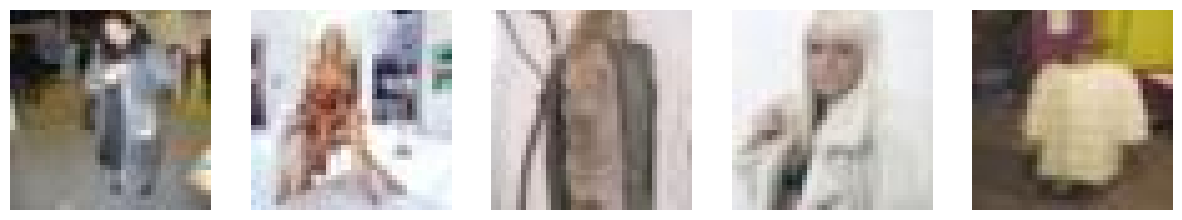

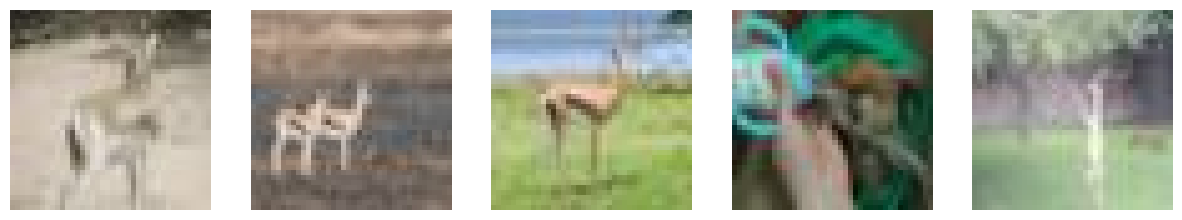

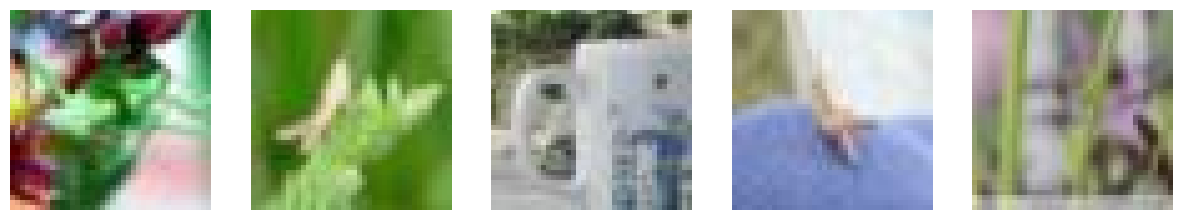

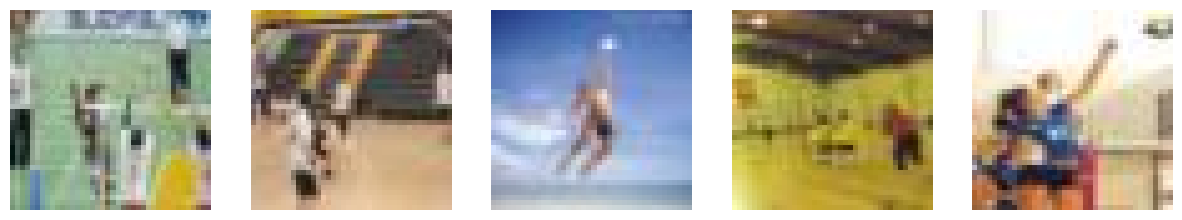

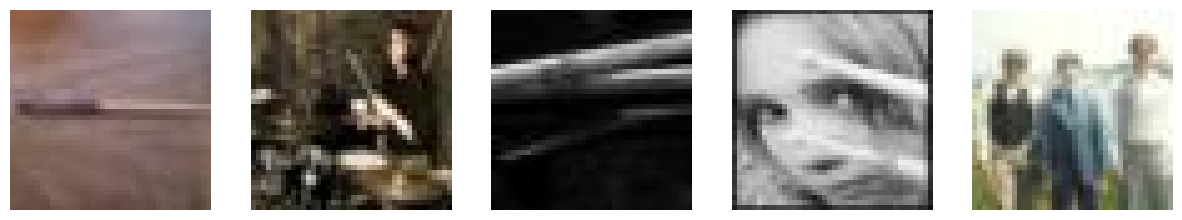

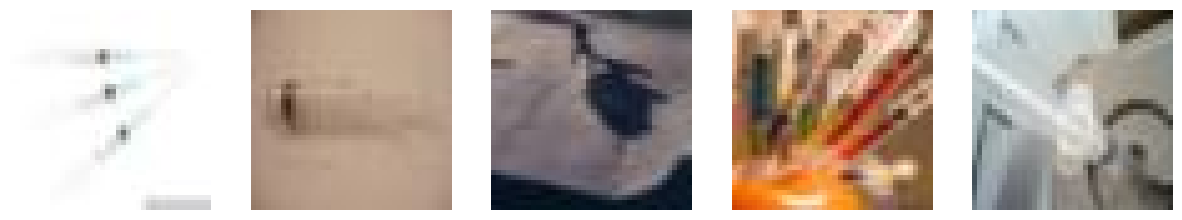

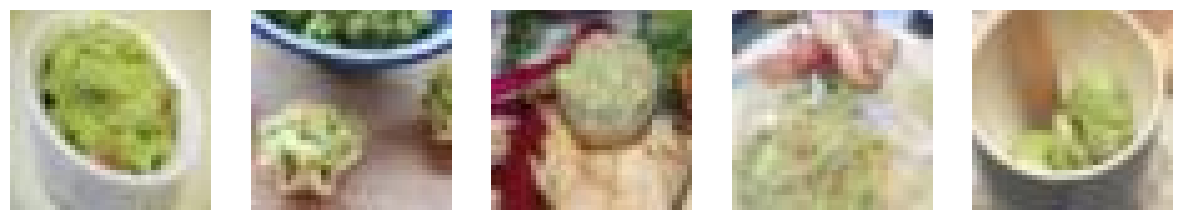

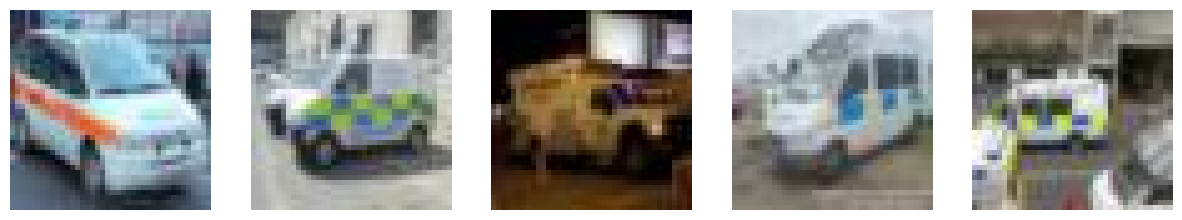

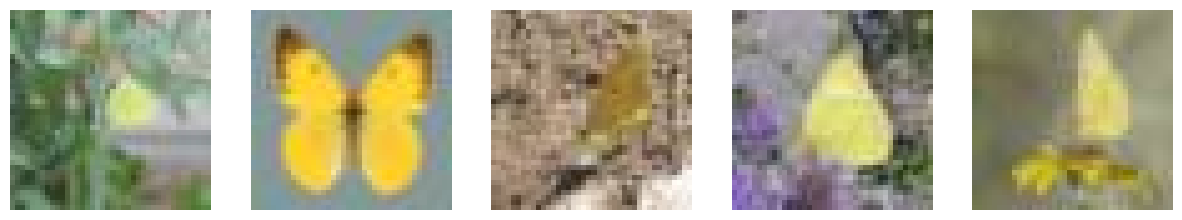

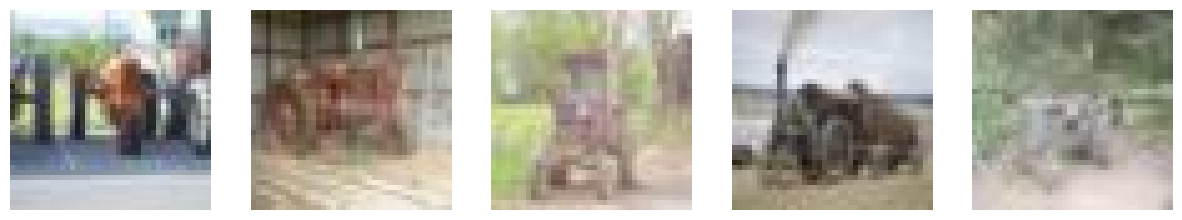

In [6]:
test_set = Custom_dataset(
    root_dir='/kaggle/input/bhw-1-dl-2025-2026/bhw1/trainval',
    csv_file='/kaggle/input/bhw-1-dl-2025-2026/bhw1/labels.csv',
    transform=None
)

n_images = 5

random_images = [random.randint(0, 499) for _ in range(n_images)]
random_classes = [random.randint(0, 199) for _ in range(10)]

for class_ in random_classes:
  indices = test_set.annotations[test_set.annotations.iloc[:, 1] == class_].index.tolist()


  fig, axes = plt.subplots(1, n_images, figsize=(15, 5))

  for i in range(len(random_images)):
      idx = indices[random_images[i]]
      img, label = test_set.__getitem__(idx)

      axes[i].imshow(img)
      axes[i].axis('off')

plt.show()

Видно, что маленькое расширение + большое количество классов делает непростой задачей даже человеку понять, какой объект подразумевает класс

#Начнем наш первый эксперимент


In [7]:
results = pd.DataFrame(columns=['name of experiment', 'accuracy'])

1) Сделаем самую обычную нейросеть без аугментаций и функций активации (лин. рег).

Accuracy = 0.04420

In [8]:
results.loc[0] = ['Network1 (Linear)', 0.04420]

2) Сделаем нейросеть с 3 слоями и функцией активации ReLU.

In [9]:
results.loc[1] = ['Network2 (Linear + ReLU)', 0.06500]

3) Теперь попробуем другие функции активации

In [10]:
results.loc[2] = ['Network3 (Linear + all activations)', 0.01720]

4) Теперь уберем sigmoid и добавим batchnorm

In [11]:
results.loc[3] = ['Network4 (Linear + batchnorm)', 0.12474]

5) Начнем работу с CNN. Построим самую тривиальную модель без padding, delution

In [12]:
results.loc[4] = ['Trivial CNN', 0.14263]

6) Сразу прыгнем к VGG

In [13]:
results.loc[5] = ['VGG', 0.17993]

7) Strong VGG

In [14]:
results.loc[6] = ['VGG', 0.254497]

8) ResNet

In [22]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(40, padding=4),
    transforms.RandAugment(num_ops=2, magnitude=8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25) 
])

transform_val = transforms.Compose([
    transforms.Resize((40, 40)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_loader = get_data_full(batch_size=128, transform_train=train_transform)

class PreActBlock(nn.Module):
    def __init__(self, in_planes, planes, stride=1):
        super(PreActBlock, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)

        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False)
            )

    def forward(self, x):

        out = torch.relu(self.bn1(x))
        shortcut = self.shortcut(out) if hasattr(self, 'shortcut') else x
        out = self.conv1(out)
        out = self.conv2(torch.relu(self.bn2(out)))
        out += shortcut
        return out

class Network11(nn.Module):
    def __init__(self, num_classes=200):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)


        self.layer1 = nn.Sequential(
            PreActBlock(64, 64, 1),
            PreActBlock(64, 64, 1),
            PreActBlock(64, 64, 1)
        )
        

        self.layer2 = nn.Sequential(
            PreActBlock(64, 128, 2), 
            PreActBlock(128, 128, 1),
            PreActBlock(128, 128, 1),
            PreActBlock(128, 128, 1)
        )
        

        self.layer3 = nn.Sequential(
            PreActBlock(128, 256, 2),
            *[PreActBlock(256, 256, 1) for _ in range(5)]
        )
        

        self.layer4 = nn.Sequential(
            PreActBlock(256, 512, 2), 
            PreActBlock(512, 512, 1),
            PreActBlock(512, 512, 1)
        )

        self.bn_final = nn.BatchNorm2d(512)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=0.4) 
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = torch.relu(self.bn_final(x)) 
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x



net = Network11(num_classes=200).to(device)
optimizer = optim.AdamW(net.parameters(), lr=1e-3, weight_decay=0.05)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=2e-3,           
    steps_per_epoch=len(full_loader), 
    epochs=40,
    pct_start=0.15,       
    anneal_strategy='cos',
    div_factor=25,         
    final_div_factor=100  
)


train_loss, train_acc, final_net = train_full(
    model=net, 
    optimizer=optimizer, 
    n_epochs=40, 
    train_loader=full_loader, 
    scheduler=scheduler,
    device=device,  
    alpha=0.2
)



test_set = Custom_dataset(root_dir='/kaggle/input/bhw-1-dl-2025-2026/bhw1/test', csv_file=None, transform=transform_val)

test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False, num_workers=2)


net.load_state_dict(final_net)

predict(net, test_loader)

Epoch 0 | LR: 0.000209
  train loss: 5.1374, train acc: 0.0231

Epoch 1 | LR: 0.000560
  train loss: 4.9333, train acc: 0.0431

Epoch 2 | LR: 0.001040
  train loss: 4.7217, train acc: 0.0717

Epoch 3 | LR: 0.001520
  train loss: 4.5862, train acc: 0.0948

Epoch 4 | LR: 0.001872
  train loss: 4.4955, train acc: 0.1127

Epoch 5 | LR: 0.002000
  train loss: 4.3802, train acc: 0.1351

Epoch 6 | LR: 0.001996
  train loss: 4.2871, train acc: 0.1531

Epoch 7 | LR: 0.001983
  train loss: 4.1976, train acc: 0.1736

Epoch 8 | LR: 0.001962
  train loss: 4.1431, train acc: 0.1870

Epoch 9 | LR: 0.001932
  train loss: 4.0508, train acc: 0.2060

Epoch 10 | LR: 0.001895
  train loss: 3.9712, train acc: 0.2232

Epoch 11 | LR: 0.001850
  train loss: 3.9248, train acc: 0.2364

Epoch 12 | LR: 0.001798
  train loss: 3.9040, train acc: 0.2431

Epoch 13 | LR: 0.001739
  train loss: 3.8316, train acc: 0.2591

Epoch 14 | LR: 0.001674
  train loss: 3.8030, train acc: 0.2686

Epoch 15 | LR: 0.001603
  train los

,Id,Category
0,test_00000.jpg,100
1,test_00001.jpg,196
2,test_00002.jpg,190
3,test_00003.jpg,140
4,test_00004.jpg,170
...,...,...
9995,test_09995.jpg,121
9996,test_09996.jpg,150
9997,test_09997.jpg,47
9998,test_09998.jpg,72


In [23]:
extra_epochs = 20


new_scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=5e-4, 
    steps_per_epoch=len(full_loader), 
    epochs=extra_epochs,
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=100
)

train_loss_2, train_acc_2, final_net_v2 = train_full(
    model=net, 
    optimizer=optimizer, 
    n_epochs=extra_epochs, 
    train_loader=full_loader, 
    scheduler=new_scheduler,
    device=device,  
    alpha=0.2
)


net.load_state_dict(final_net_v2)
predict(net, test_loader)

Epoch 0 | LR: 0.000275
  train loss: 2.9317, train acc: 0.4990

Epoch 1 | LR: 0.000500
  train loss: 3.0029, train acc: 0.4783

Epoch 2 | LR: 0.000496
  train loss: 3.0375, train acc: 0.4675

Epoch 3 | LR: 0.000485
  train loss: 3.0165, train acc: 0.4750

Epoch 4 | LR: 0.000467
  train loss: 3.0095, train acc: 0.4757

Epoch 5 | LR: 0.000442
  train loss: 3.0490, train acc: 0.4699

Epoch 6 | LR: 0.000411
  train loss: 2.9906, train acc: 0.4814

Epoch 7 | LR: 0.000375
  train loss: 2.9694, train acc: 0.4909

Epoch 8 | LR: 0.000336
  train loss: 2.8750, train acc: 0.5116

Epoch 9 | LR: 0.000294
  train loss: 2.9342, train acc: 0.5017

Epoch 10 | LR: 0.000250
  train loss: 2.8323, train acc: 0.5257

Epoch 11 | LR: 0.000207
  train loss: 2.8189, train acc: 0.5303

Epoch 12 | LR: 0.000165
  train loss: 2.7747, train acc: 0.5440

Epoch 13 | LR: 0.000125
  train loss: 2.7395, train acc: 0.5522

Epoch 14 | LR: 0.000090
  train loss: 2.7066, train acc: 0.5588

Epoch 15 | LR: 0.000059
  train los

,Id,Category
0,test_00000.jpg,100
1,test_00001.jpg,196
2,test_00002.jpg,190
3,test_00003.jpg,140
4,test_00004.jpg,170
...,...,...
9995,test_09995.jpg,121
9996,test_09996.jpg,150
9997,test_09997.jpg,47
9998,test_09998.jpg,72


In [ ]:
extra_epochs = 5


new_scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=1e-4, 
    steps_per_epoch=len(full_loader), 
    epochs=extra_epochs,
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=100
)

train_loss_2, train_acc_2, final_net_v2 = train_full(
    model=net, 
    optimizer=optimizer, 
    n_epochs=extra_epochs, 
    train_loader=full_loader, 
    scheduler=new_scheduler,
    device=device,  
    alpha=0.2
)


net.load_state_dict(final_net_v2)
predict(net, test_loader)

Epoch 0 | LR: 0.000097
  train loss: 2.6380, train acc: 0.5795

Epoch 1 | LR: 0.000075
  train loss: 2.6736, train acc: 0.5687

Epoch 2 | LR: 0.000041
  train loss: 2.6863, train acc: 0.5684

Epoch 3 | LR: 0.000012
  train loss: 2.6672, train acc: 0.5726



In [24]:
def predict_smart_tta(model, loader, device):
    model.eval()
    ids = []
    all_probs = []

    with torch.no_grad():
        for data, file_names in loader:
            data = data.to(device)


            p1 = torch.softmax(model(data), dim=1)
            

            p2 = torch.softmax(model(torch.flip(data, dims=[3])), dim=1)
            

            p3 = torch.softmax(model(torch.roll(data, shifts=2, dims=2)), dim=1)
            p4 = torch.softmax(model(torch.roll(data, shifts=-2, dims=3)), dim=1)

            avg_probs = p1 * 0.4 + p2 * 0.2 + p3 * 0.2 + p4 * 0.2
            
            preds = avg_probs.argmax(dim=1)

            ids.extend(file_names)
            all_probs.extend(preds.cpu().numpy())

    submission = pd.DataFrame({'Id': ids, 'Category': all_probs})
    submission['Id'] = submission['Id'].apply(lambda x: os.path.basename(x))
    submission.to_csv('labels_test.csv', index=False)
    return submission

predict_smart_tta(net, test_loader, device)

,Id,Category
0,test_00000.jpg,100
1,test_00001.jpg,196
2,test_00002.jpg,190
3,test_00003.jpg,140
4,test_00004.jpg,170
...,...,...
9995,test_09995.jpg,121
9996,test_09996.jpg,150
9997,test_09997.jpg,47
9998,test_09998.jpg,72


In [ ]:
torch.save(best_net, 'best_model_checkpoint.pth')